# 1. importing libraries

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

import shap

# 2.Loading dataset

In [136]:
data = pd.read_csv("landslide_prediction_dataset.csv")

In [137]:
print(data.head())


   label  elevation_m  slope_deg  aspect_deg  curvature       twi        spi  \
0      1        313.0  21.359993  330.255127  -0.004706  4.797907  18.546377   
1      1        811.0  19.749323   97.765167   0.002615  4.795339  15.589594   
2      1       3531.0  36.334282   33.340706   0.006275  4.441133  45.911213   
3      1       2852.0  25.889961  271.909149   0.003137  4.560648  22.531372   
4      1       1665.0  11.559339  341.565063   0.000261  5.248601   7.960804   

   roughness  soil_type  distance_to_fault_m  ...  rainfall_7d_mm  \
0  10.349366        0.0         12272.731608  ...            35.3   
1   8.533024        0.0         42494.473686  ...           129.8   
2  17.944359       18.0         30496.557271  ...           129.8   
3  14.247807        6.0        106647.220855  ...           125.0   
4   6.403124        6.0         30510.046635  ...            26.9   

   soil_moisture  earthquake_count_7d  earthquake_count_30d  \
0          0.410                  0.0    

In [138]:
print(data.shape)


(1411, 30)


In [139]:
print(data.columns)

Index(['label', 'elevation_m', 'slope_deg', 'aspect_deg', 'curvature', 'twi',
       'spi', 'roughness', 'soil_type', 'distance_to_fault_m',
       'distance_to_road_m', 'distance_to_river_m', 'drainage_density',
       'building_density', 'ndvi_baseline', 'lulc', 'rainfall_1h_mm',
       'rainfall_3h_mm', 'rainfall_24h_mm', 'rainfall_3d_mm', 'rainfall_7d_mm',
       'soil_moisture', 'earthquake_count_7d', 'earthquake_count_30d',
       'max_earthquake_magnitude', 'distance_to_recent_earthquake_m',
       'soil_sand', 'soil_silt', 'soil_clay', 'lithology_encoded'],
      dtype='object')


## 3.Checking distribution

In [140]:
print(data["label"].value_counts())

label
1    706
0    705
Name: count, dtype: int64


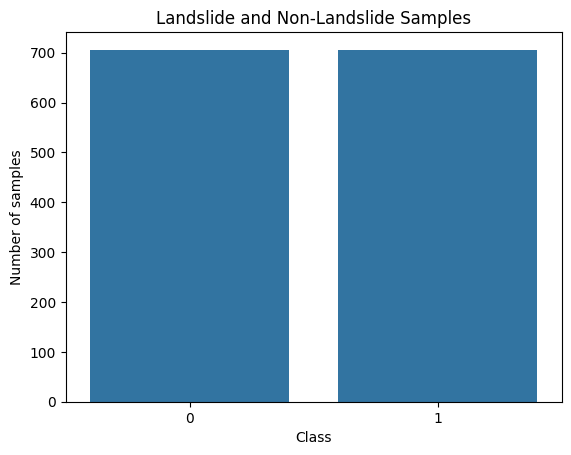

In [141]:
sns.countplot(x="label", data=data)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Landslide and Non-Landslide Samples")
plt.show()

## 4. Separate input parameters and target

In [143]:
X = data.drop(columns=["label"])
y = data["label"]

### Checking

In [144]:
print("Number of input parameters:", X.shape[1])
print("Number of samples:", X.shape[0])

Number of input parameters: 29
Number of samples: 1411


## 5.Checking missing values

In [145]:
print(data.isnull().sum())

label                              0
elevation_m                        0
slope_deg                          0
aspect_deg                         0
curvature                          0
twi                                0
spi                                0
roughness                          0
soil_type                          0
distance_to_fault_m                0
distance_to_road_m                 0
distance_to_river_m                0
drainage_density                   0
building_density                   0
ndvi_baseline                      0
lulc                               0
rainfall_1h_mm                     0
rainfall_3h_mm                     0
rainfall_24h_mm                    0
rainfall_3d_mm                     0
rainfall_7d_mm                     0
soil_moisture                      0
earthquake_count_7d                0
earthquake_count_30d               0
max_earthquake_magnitude           0
distance_to_recent_earthquake_m    0
soil_sand                          0
s

### checking dupplicate records

In [146]:
print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


## 6. Performing 80:20 split

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### checking sizes

In [148]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 1128
Testing samples: 283

Training class distribution:
label
0    564
1    564
Name: count, dtype: int64

Testing class distribution:
label
1    142
0    141
Name: count, dtype: int64


## 7. Making the training data exactly balanced 

In [149]:
# using equal no. of positive and negative occurences during training to reduce bias
train_data = pd.concat([X_train, y_train], axis=1)

class_0 = train_data[train_data["label"] == 0]
class_1 = train_data[train_data["label"] == 1]

print("Class 0:", len(class_0))
print("Class 1:", len(class_1))

Class 0: 564
Class 1: 564


### Finding smaller class

In [150]:
n_samples = min(len(class_0), len(class_1))

class_0_balanced = class_0.sample(
    n=n_samples,
    random_state=42
)

class_1_balanced = class_1.sample(
    n=n_samples,
    random_state=42
)

### combining them

In [151]:
train_balanced = pd.concat(
    [class_0_balanced, class_1_balanced]
)

train_balanced = train_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

### separating X & y again

In [152]:
train_balanced = pd.concat(
    [class_0_balanced, class_1_balanced]
)

train_balanced = train_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

### verifying

In [153]:
print(y_train.value_counts())

label
0    564
1    564
Name: count, dtype: int64


## 7. Building xgboost model

In [154]:
#model = XGBClassifier(
#    n_estimators=300,
 #   max_depth=4,
#    learning_rate=0.05,
  #  subsample=0.8,
   # colsample_bytree=0.8,
  #  objective="binary:logistic",
   # eval_metric="logloss",
    #random_state=42
#)

model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

## 8. Training model

In [155]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


## 9.making prediction on test data

In [156]:
y_pred = model.predict(X_test)

### obtaining probability of landslide

In [158]:
y_prob = model.predict_proba(X_test)[:, 1]

## 10.Calculating accuracy

In [159]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.901060070671378


### for percentage

In [160]:
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 90.11%


## 11. calculating precision,recall & F1 score

In [161]:
#In landslide prediction:
#Precision = proportion of predicted landslides that are actually landslides.
#Recall/Sensitivity = proportion of actual landslides correctly identified.
#F1-score = balance between precision and recall.


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8958333333333334
Recall: 0.9084507042253521
F1-score: 0.9020979020979021


## 12.calculating ROC-AUC

In [162]:
#AUC is especially useful because it evaluates the model's ability to distinguish landslide from non-landslide cases across different probability thresholds.


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9666366996304065


## 13. Generating complete clasificaion report

In [163]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Landslide", "Landslide"]
))

               precision    recall  f1-score   support

Non-Landslide       0.91      0.89      0.90       141
    Landslide       0.90      0.91      0.90       142

     accuracy                           0.90       283
    macro avg       0.90      0.90      0.90       283
 weighted avg       0.90      0.90      0.90       283



## 14. Calculating specificity

In [164]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)

print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive:", TP)
print("Specificity:", specificity)

True Negative: 126
False Positive: 15
False Negative: 13
True Positive: 129
Specificity: 0.8936170212765957


## 15. Plotting confusion matrix

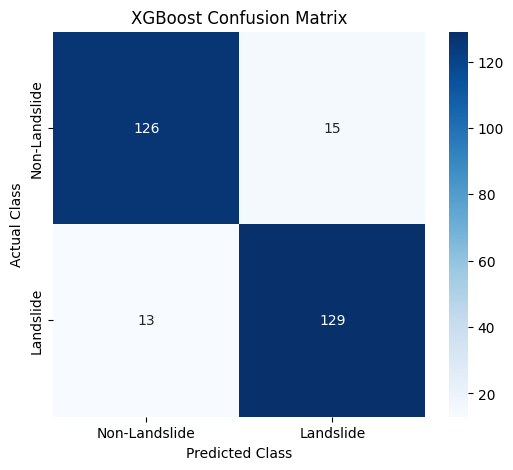

In [165]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Landslide", "Landslide"],
    yticklabels=["Non-Landslide", "Landslide"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("XGBoost Confusion Matrix")

plt.show()

## 16. plottting ROC curve

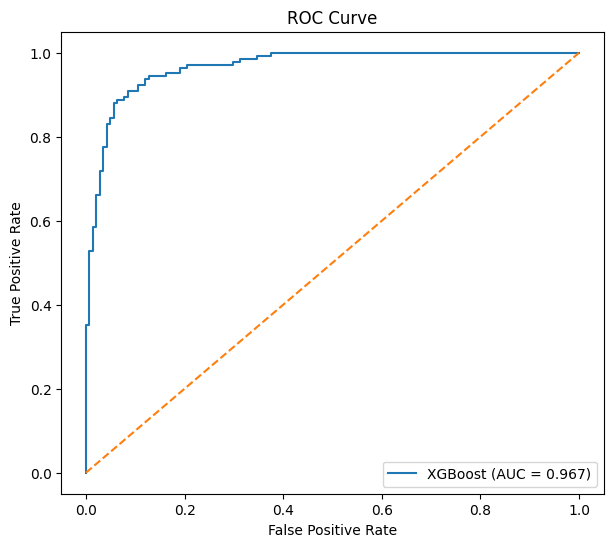

In [166]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="XGBoost (AUC = {:.3f})".format(auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 17. Determining xgboost feature importance

In [77]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Parameter": X_train.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                          Parameter  Importance
9                distance_to_road_m    0.172972
19                   rainfall_7d_mm    0.084180
10              distance_to_river_m    0.071832
12                 building_density    0.071529
18                   rainfall_3d_mm    0.070154
23         max_earthquake_magnitude    0.066493
20                    soil_moisture    0.050160
22             earthquake_count_30d    0.045753
17                  rainfall_24h_mm    0.040068
28                lithology_encoded    0.028776
11                 drainage_density    0.025503
6                         roughness    0.025184
21              earthquake_count_7d    0.023902
5                               spi    0.023664
24  distance_to_recent_earthquake_m    0.022281
1                         slope_deg    0.019535
26                        soil_silt    0.019335
4                               twi    0.018435
25                        soil_sand    0.015862
0                       elevation_m    0

## 18. PLotting 29 parameter importance values

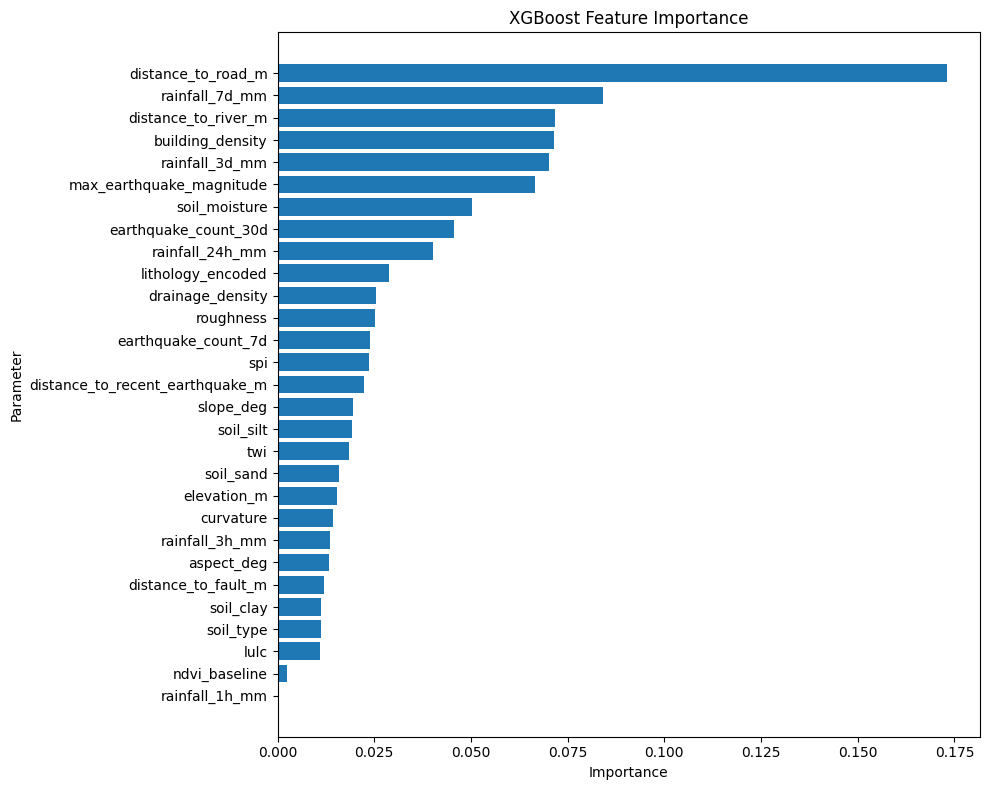

In [167]:
#This will tell you which terrain/climate parameters are most influential

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Parameter"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Parameter")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 19. Saving feature importance result

In [168]:
feature_importance.to_excel(
    "XGBoost_Feature_Importance.xlsx",
    index=False
)

## 20. SHAP analysis

### SHAP explainer

In [169]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

### SHAP summary plot

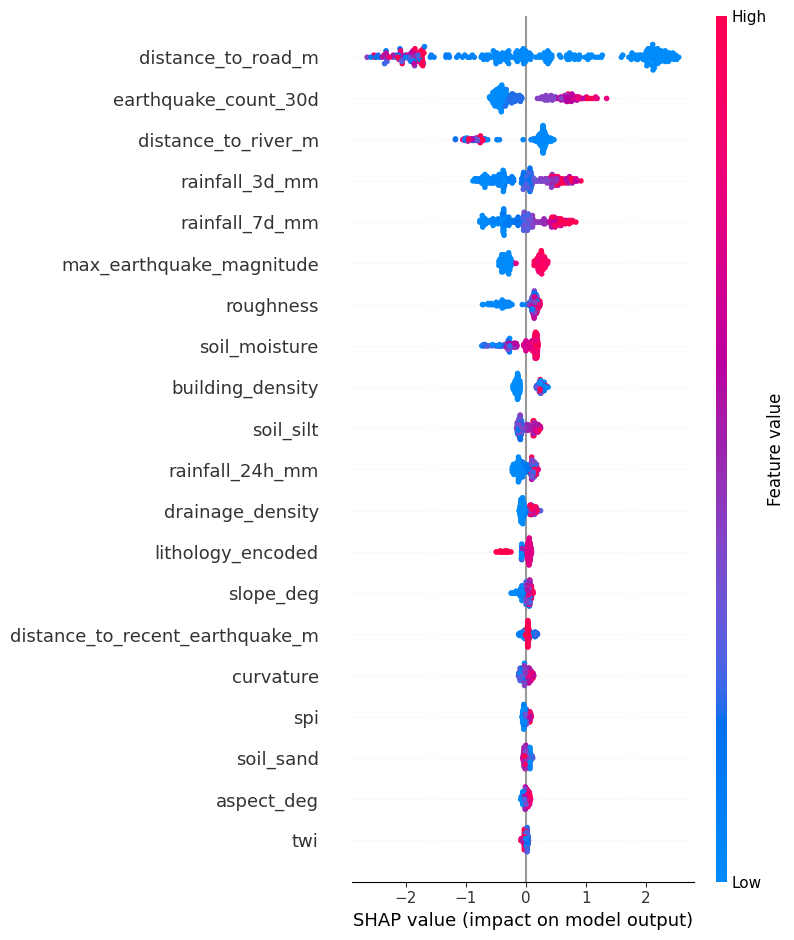

In [172]:
#This gives you the overall importance and direction of influence of each parameter.
#For example, it can show whether high values of a particular parameter generally increase or decrease landslide probability.

shap.summary_plot(
    shap_values,
    X_test
)

### SHAP barplot

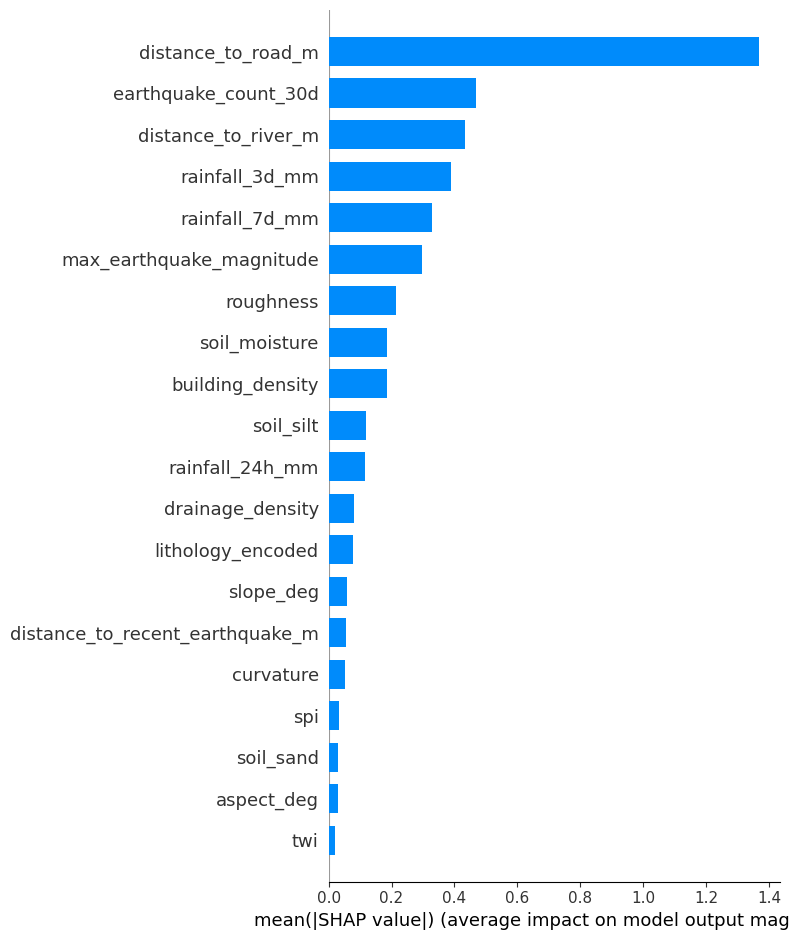

In [83]:
#This provides a ranked list of the most influential parameters.

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

##  21. Saving trained xgboost model

In [173]:
model.save_model("XGBoost_Landslide_Model.json")

### For Loading

In [174]:
model_loaded = XGBClassifier()

model_loaded.load_model(
    "XGBoost_Landslide_Model.json"
)

## 22. Creating one final performance table

In [175]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Specificity",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        auc
    ]
})

print(results)

        Metric     Score
0     Accuracy  0.901060
1    Precision  0.895833
2       Recall  0.908451
3     F1-score  0.902098
4  Specificity  0.893617
5      ROC-AUC  0.966637


### Saving

In [176]:
results.to_excel(
    "XGBoost_Model_Performance.xlsx",
    index=False
)

In [177]:
# ===============================
# OVERFITTING CHECK
# ===============================

# Training predictions
y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]

# Test predictions
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# AUC
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("================================")
print("OVERFITTING ASSESSMENT")
print("================================")

print("Training Accuracy: {:.2f}%".format(
    train_accuracy * 100
))

print("Test Accuracy: {:.2f}%".format(
    test_accuracy * 100
))

print("Accuracy Gap: {:.2f}%".format(
    (train_accuracy - test_accuracy) * 100
))

print()

print("Training ROC-AUC: {:.4f}".format(
    train_auc
))

print("Test ROC-AUC: {:.4f}".format(
    test_auc
))

print("AUC Gap: {:.4f}".format(
    train_auc - test_auc
))

OVERFITTING ASSESSMENT
Training Accuracy: 94.33%
Test Accuracy: 90.11%
Accuracy Gap: 4.22%

Training ROC-AUC: 0.9932
Test ROC-AUC: 0.9666
AUC Gap: 0.0266
